<a href="https://colab.research.google.com/github/JanTeichertKluge/demand-analysis-labs/blob/main/v2_ext/03_predicting_price_and_quantities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Prices and Quantities with Product Embeddings

This notebook is the third of five labs that accompany [Bach et al. (2025)](https://arxiv.org/abs/2501.00382). It requires the embeddings saved in **Lab 2**.

Before we estimate a causal effect, it is useful to know what the controls can predict. In the partially linear model of Lab 4,

$$Q_{it}^{\perp} = \delta\, P_{it}^{\perp} + e_{it}, \qquad
Q^{\perp}_{it} := Q_{it} - E[Q_{it}\mid S_{it}], \quad
P^{\perp}_{it} := P_{it} - E[P_{it}\mid S_{it}],$$

everything rests on the two nuisance functions $E[Q\mid S]$ and $E[P\mid S]$. In this lab, we measure how well we can estimate them and which kind of variation the fine-tuned embeddings explain.

## Four Prediction Targets

We consider the levels and the changes of both signals:

| Target | Meaning |
|---|---|
| $Q_{it}$ | level of the quantity signal |
| $P_{it}$ | level of the price signal |
| $\Delta Q_{it}$ | period-to-period change in the quantity signal |
| $\Delta P_{it}$ | period-to-period change in the price signal |

A confounder of the price-quantity relationship has to explain changes, since it must move price and quantity together over time. A variable that only explains levels, that is, why one product is generally more expensive or sells better than another, is largely absorbed by the product's own history and does not bias the elasticity much. It can still tell us for which products the elasticity is large or small.

The gap between levels and changes therefore determines whether the embeddings act as confounders, which is the concern of Lab 4, or as effect modifiers, which is the topic of Lab 5.

We fit all models on the fine-tuning products and evaluate them on the estimation products, which are entirely held out. Following the paper, we report negative out-of-sample $R^2$ values as 0.

First, we install and load the required packages.

In [1]:
%pip install -q lightgbm

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

palette = sns.color_palette("colorblind")
pd.set_option("display.width", 140)

## Data

We load the data saved in Lab 2 from Google Drive. If the file is not found there, the cell also looks for a copy uploaded to the current session.

In [3]:
ARTIFACT = "full_v2_ext.parquet"
drive_path = f"/content/drive/MyDrive/demand_labs_v2_ext/{ARTIFACT}"

# Colab gives every notebook its own machine, so /content does not carry across
# labs. Google Drive does.
if os.path.isdir("/content") and not os.path.exists(drive_path):
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        print(f"could not mount Drive ({type(exc).__name__})")

path = next((p for p in [drive_path, f"/content/{ARTIFACT}", ARTIFACT]
             if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError(
        f"{ARTIFACT} not found. Run Lab 2 "
        "(02_finetune_embeddings.ipynb) first and let it save to Google Drive, "
        "or upload the file into this session.")

df = pd.read_parquet(path)
print(f"loaded {path}")
print(f"{df['ASIN'].nunique():,} products, {len(df):,} rows, "
      f"{df['period'].nunique()} periods")
print(df.groupby("split").agg(products=("ASIN", "nunique"), rows=("ASIN", "size"),
                              in_sample=("in_sample", "sum")))

Mounted at /content/drive
loaded /content/drive/MyDrive/demand_labs_v2_ext/full_v2_ext.parquet
7,549 products, 83,777 rows, 14 periods
            products   rows  in_sample
split                                 
estimation      3775  41736      37940
finetune        3774  42041      38247


The data contain 7,549 products and 83,777 product-periods, split by product into 3,774 fine-tuning and 3,775 estimation products. We use the rows the paper keeps: 38,247 observations of fine-tuning products for training and 37,940 observations of estimation products for testing.

## Feature Sets

Following Tables 5 and 6 of the paper, we consider four nested specifications:

* **Tabular**: human-coded features only, that is, subcategory and period dummies and the time-varying controls, but no embeddings.
* **+ 5 PCA**: adds the first five principal components of $X^e$.
* **+ 5 Similarities**: adds the five cosine similarities to the $k$-means centroids.
* **+ 256 Embeddings**: adds the full projected embedding.

All four include the time-varying tabular controls (lagged rating and review count, offer counts, deal and FBA indicators). We estimate each specification twice: once without lagged $Q$ and $P$, which corresponds to the comparison in Tables 5 and 6 of the paper, and once with them, which corresponds to the full state $S_{it}$ that Lab 4 conditions on. The contrast between the two is the main point of this lab.

In [4]:
emb_cols = [c for c in df.columns if c.startswith("emb_")]
pca_cols = [c for c in df.columns if c.startswith("pca_")]
sim_cols = [c for c in df.columns if c.startswith("similarity_cluster_")]
sub_cols = [c for c in df.columns if c.startswith("sub_")]

lag_controls = ["Q_t-1", "P_bb_t-1"]
tab_controls = ["RATING_t-1", "REVIEW_COUNT_t-1", "n_offers",
                "n_offers_fba", "n_offers_fbm", "lightning_deal", "is_fba"]

periods = sorted(df["period"].unique())[1:]   # first period is the baseline
period_cols = [f"period_{p}" for p in periods]
for p in periods:
    df[f"period_{p}"] = (df["period"] == p).astype(int)

BASE = sub_cols + period_cols + tab_controls
FEATURE_SETS = {
    "Tabular":          BASE,
    "+ 5 PCA":          BASE + pca_cols,
    "+ 5 Similarities": BASE + sim_cols,
    "+ 256 Embeddings": BASE + emb_cols,
}
STATE = lag_controls + tab_controls   # dropna basis: same rows for every spec
TARGETS = ["Q_t", "P_bb_t", "Delta_Q_t", "Delta_P_bb_t"]

print(f"{len(emb_cols)} embeddings | {len(pca_cols)} PCA | {len(sim_cols)} "
      f"similarities | {len(sub_cols)} subcategories | {len(period_cols)} periods")

256 embeddings | 5 PCA | 5 similarities | 11 subcategories | 13 periods


## Estimation

For every combination of feature set, lag specification and target, we fit a linear regression by OLS and gradient boosted trees (LightGBM). The first period of each product has no lagged values and is dropped throughout, so every specification is evaluated on the same observations.

In [5]:
# rows with a lagged state: I_1 for training, I_2 for testing
data = df[df["in_sample"]].dropna(subset=STATE + TARGETS).copy()
train = data[data["split"] == "finetune"]
test = data[data["split"] == "estimation"]
print(f"train: {len(train):,} rows ({train['ASIN'].nunique()} products)   "
      f"test: {len(test):,} rows ({test['ASIN'].nunique()} products)")


def score(features, target):
    """Out-of-sample R^2 for OLS and LightGBM; negatives clipped to 0."""
    X_tr, X_te = train[features], test[features]
    y_tr, y_te = train[target], test[target]

    ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
    r2_ols = r2_score(y_te, ols.predict(sm.add_constant(X_te, has_constant="add")))

    gbm = LGBMRegressor(n_estimators=500, learning_rate=0.02,
                        random_state=42, verbose=-1).fit(X_tr, y_tr)
    r2_gbm = r2_score(y_te, gbm.predict(X_te))

    return {"OLS": max(r2_ols, 0.0), "LightGBM": max(r2_gbm, 0.0)}


rows = []
for with_lags in (False, True):
    label = "with lagged Q,P" if with_lags else "no lagged Q,P"
    for name, feats in FEATURE_SETS.items():
        cols = feats + (lag_controls if with_lags else [])
        for target in TARGETS:
            for model, value in score(cols, target).items():
                rows.append({"Controls": label, "Features": name, "Model": model,
                             "Target": target, "R2": value})
        print(f"  {label:13s} | {name:18s} done", flush=True)

results = pd.DataFrame(rows)

train: 38,247 rows (3699 products)   test: 37,940 rows (3726 products)


/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()


  no lagged Q,P | Tabular            done


/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()


  no lagged Q,P | + 5 PCA            done


...

  with lagged Q,P | + 5 PCA            done


/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()


  with lagged Q,P | + 5 Similarities   done


/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2282/1850281918.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()


  with lagged Q,P | + 256 Embeddings   done


## Results

The training sample contains 38,247 observations of 3,699 products and the test sample 37,940 observations of 3,726 products; the remaining products are observed in only one period and have no lagged values. The table reports the out-of-sample $R^2$ in percent, and the figure below shows the LightGBM results graphically.

**Note:** The `SingularMatrixWarning`s above indicate that the OLS design matrix is rank-deficient, since the full set of subcategory dummies is collinear with the constant. `statsmodels` then uses a pseudo-inverse, and the predictions remain well defined.

In [6]:
table = (results
         .pivot_table(index=["Controls", "Features", "Model"], columns="Target",
                      values="R2")
         .reindex(columns=TARGETS)
         .reindex(["no lagged Q,P", "with lagged Q,P"], level="Controls")
         .reindex(list(FEATURE_SETS), level="Features"))
print("Out-of-sample R^2 (%)")
(table * 100).round(2)

Out-of-sample R^2 (%)


Target                                       Q_t  P_bb_t  Delta_Q_t  Delta_P_bb_t
Controls        Features         Model                                           
no lagged Q,P   Tabular          LightGBM  47.41   22.32      14.38          1.69
                                 OLS       20.82   15.58       7.84          0.60
                + 5 PCA          LightGBM  52.53   61.21      16.69          2.16
                                 OLS       47.51   57.80       7.84          0.61
                + 5 Similarities LightGBM  53.81   60.08      16.60          2.13
                                 OLS       47.48   56.88       7.85          0.64
                + 256 Embeddings LightGBM  53.29   61.65      15.27          2.08
                                 OLS       48.25   60.62       7.71          0.37
with lagged Q,P Tabular          LightGBM  90.53   97.46      19.64          2.60
                                 OLS       89.61   97.94      11.33          1.62
                + 5 PCA          LightGBM  89.41   97.23       7.74          0.00
                                 OLS       89.10   97.89       7.02          0.00
                + 5 Similarities LightGBM  89.35   97.08       4.50          0.00
                                 OLS       88.97   97.90       5.94          0.00
                + 256 Embeddings LightGBM  88.86   97.39       5.63          0.00
                                 OLS       87.53   97.76       0.00          0.00

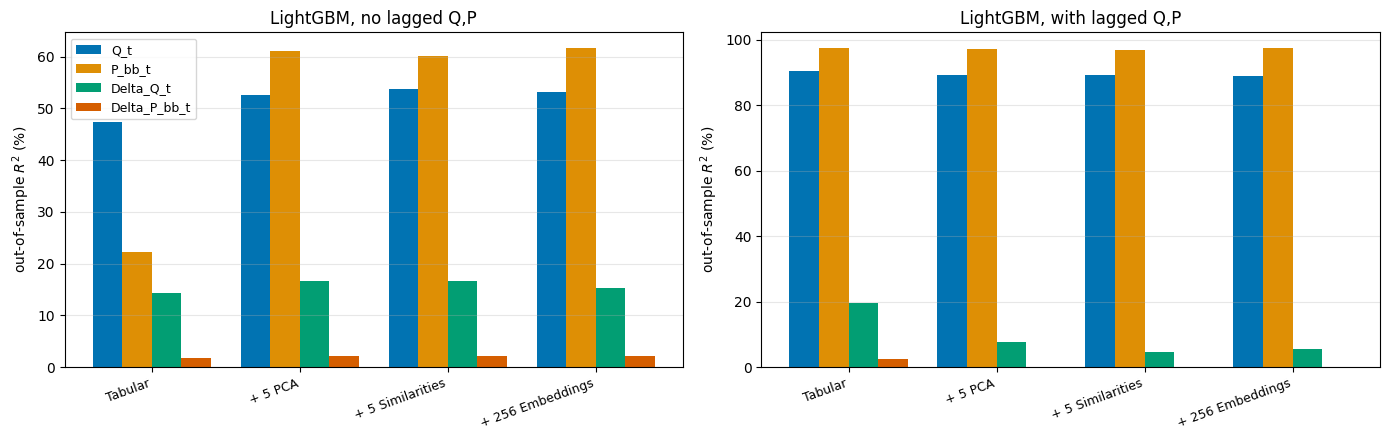

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, state in zip(axes, ["no lagged Q,P", "with lagged Q,P"]):
    sub = results[(results["Controls"] == state) & (results["Model"] == "LightGBM")]
    wide = sub.pivot(index="Features", columns="Target",
                     values="R2").reindex(list(FEATURE_SETS))
    x = np.arange(len(wide))
    for i, t in enumerate(TARGETS):
        ax.bar(x + (i - 1.5) * 0.2, wide[t] * 100, 0.2, label=t, color=palette[i])
    ax.set_xticks(x)
    ax.set_xticklabels(wide.index, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("out-of-sample $R^2$ (%)")
    ax.set_title(f"LightGBM, {state}")
    ax.grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

## Discussion

**About the numbers in the text.** Results that involve the embeddings depend on your run of Lab 2, so the text compares them with the paper rather than quoting fixed values. Our split differs from the paper's, so even specifications without embeddings give somewhat different numbers than the paper.

**Without lagged $Q$ and $P$, the embeddings mainly help to predict the price level.** With tabular features only, LightGBM reaches an out-of-sample $R^2$ of about 47% for $Q_{it}$ but only about 22% for $P_{it}$ (16% with OLS). In the paper, adding the embeddings raises the $R^2$ for $P_{it}$ to between 57% and 66% (Table 6), and for OLS, the $R^2$ for $Q_{it}$ more than doubles. Check whether your rows show the same jump. A subcategory label is a coarse summary of a product, and the description and the image carry much of the information that determines its price.

**Five summaries do about as well as 256 dimensions.** In the paper, the five principal components and the five cluster similarities perform almost as well as the full 256-dimensional embedding. This is what allows Lab 5 to use five similarities as effect modifiers: the heterogeneity model remains small enough to interpret without discarding much information.

**Changes are much harder to predict than levels.** With tabular features only, the $R^2$ for $\Delta Q_{it}$ is about 14% (LightGBM) and for $\Delta P_{it}$ below 2%. The paper finds the same pattern with embeddings: the best models reach roughly 50% to 60% $R^2$ for $Q_{it}$ and 65% for $P_{it}$, but only about 15% for $\Delta Q_{it}$ and 1.5% for $\Delta P_{it}$.

**Once the lagged state is included, the embeddings add little.** With lagged $Q$ and $P$ in the model, the tabular baseline already reaches about 90% for $Q_{it}$ and 98% for $P_{it}$, so there is little room left for the embeddings to improve the prediction of levels. The lagged quantity $Q_{i,t-1}$ already reflects how popular and how visible a product is, which is most of what the description and the image tell us. This is the paper's finding that lagged quantity is the key confounder, and it is the reason why Lab 4 builds its state around it.